In [ ]:


import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


In [ ]:
# LOAD IMAGES

img1_bgr = cv2.imread("image1.png")
img2_bgr = cv2.imread("image2.png")


img1 = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)

print("Image 1 shape:", img1.shape)
print("Image 2 shape:", img2.shape)


Image 1 shape: (420, 512, 3)
Image 2 shape: (420, 512, 3)


In [ ]:
# STEP 1 – GRAYSCALE CONVERSION

gray1 = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)



In [23]:
# STEP 2 – HISTOGRAM VISUALIZATION

# A histogram counts how many pixels have each brightness level (0-255).
# A bright image has most values near 255; a dark image near 0.


In [ ]:
# STEP 3 – IMAGE RESIZING

resized1 = cv2.resize(img1, (200, 150))  
resized2 = cv2.resize(img2, (200, 150))


In [25]:
# STEP 4 – EDGE DETECTION (Canny)

# Canny finds rapid intensity changes (edges) using two thresholds.
edges1 = cv2.Canny(gray1, threshold1=50, threshold2=150)
edges2 = cv2.Canny(gray2, threshold1=50, threshold2=150)


In [26]:
# STEP 5 – NOISE ADDITION

def add_gaussian_noise(image, mean=0, sigma=30):
    noise = np.random.normal(mean, sigma, image.shape).astype(np.int16)
    noisy = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return noisy

noisy1 = add_gaussian_noise(img1)
noisy2 = add_gaussian_noise(img2)


In [27]:
# STEP 6 – GAUSSIAN DENOISING

denoised1 = cv2.GaussianBlur(noisy1, ksize=(5, 5), sigmaX=1.5)
denoised2 = cv2.GaussianBlur(noisy2, ksize=(5, 5), sigmaX=1.5)


In [28]:
# STEP 7 – PLOT EVERYTHING

fig = plt.figure(figsize=(18, 20))
fig.suptitle("Image Processing Pipeline", fontsize=18,
             fontweight="bold", y=0.98)

gs = gridspec.GridSpec(6, 4, figure=fig, hspace=0.45, wspace=0.3)

def show(ax, img, title, cmap=None):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.axis("off")


<Figure size 1800x2000 with 0 Axes>

In [29]:
# Row 0 – Original Images

show(fig.add_subplot(gs[0, 0]), img1, "Image 1 – Original")
show(fig.add_subplot(gs[0, 2]), img2, "Image 2 – Original (X-ray)")


In [30]:
# Row 1 – Grayscale Images

show(fig.add_subplot(gs[1, 0]), gray1, "Image 1 – Grayscale", cmap="gray")
show(fig.add_subplot(gs[1, 2]), gray2, "Image 2 – Grayscale", cmap="gray")


In [31]:
# Row 2 – Histograms

ax_h1 = fig.add_subplot(gs[2, :2])

for i, (col, label) in enumerate(
    zip(cv2.split(img1_bgr), ("Blue", "Green", "Red"))
):
    ax_h1.plot(
        cv2.calcHist([col], [0], None, [256], [0, 256]),
        color=["blue", "green", "red"][i],
        label=label,
        alpha=0.7,
    )

ax_h1.set_title("Image 1 – Histogram (RGB channels)", fontweight="bold")
ax_h1.set_xlabel("Pixel intensity")
ax_h1.set_ylabel("Count")
ax_h1.legend()

ax_h2 = fig.add_subplot(gs[2, 2:])
ax_h2.plot(
    cv2.calcHist([gray2], [0], None, [256], [0, 256]),
    color="gray"
)
ax_h2.set_title("Image 2 – Histogram (Grayscale)", fontweight="bold")
ax_h2.set_xlabel("Pixel intensity")
ax_h2.set_ylabel("Count")


Text(0, 0.5, 'Count')

In [32]:
# Row 3 – Resized Images

show(fig.add_subplot(gs[3, 0]), resized1, "Image 1 – Resized (200×150)")
show(fig.add_subplot(gs[3, 2]), resized2, "Image 2 – Resized (200×150)")


In [33]:
# Row 4 – Edge Detection

show(fig.add_subplot(gs[4, 0]), edges1, "Image 1 – Edges (Canny)", cmap="gray")
show(fig.add_subplot(gs[4, 2]), edges2, "Image 2 – Edges (Canny)", cmap="gray")


In [34]:
# Row 5 – Noise and Denoising

show(fig.add_subplot(gs[5, 0]), noisy1, "Image 1 – Noisy")
show(fig.add_subplot(gs[5, 1]), denoised1, "Image 1 – Denoised (Gaussian)")
show(fig.add_subplot(gs[5, 2]), noisy2, "Image 2 – Noisy")
show(fig.add_subplot(gs[5, 3]), denoised2, "Image 2 – Denoised (Gaussian)")


In [35]:
print("Number of axes:", len(fig.axes))


Number of axes: 14


Saved → image_output.png


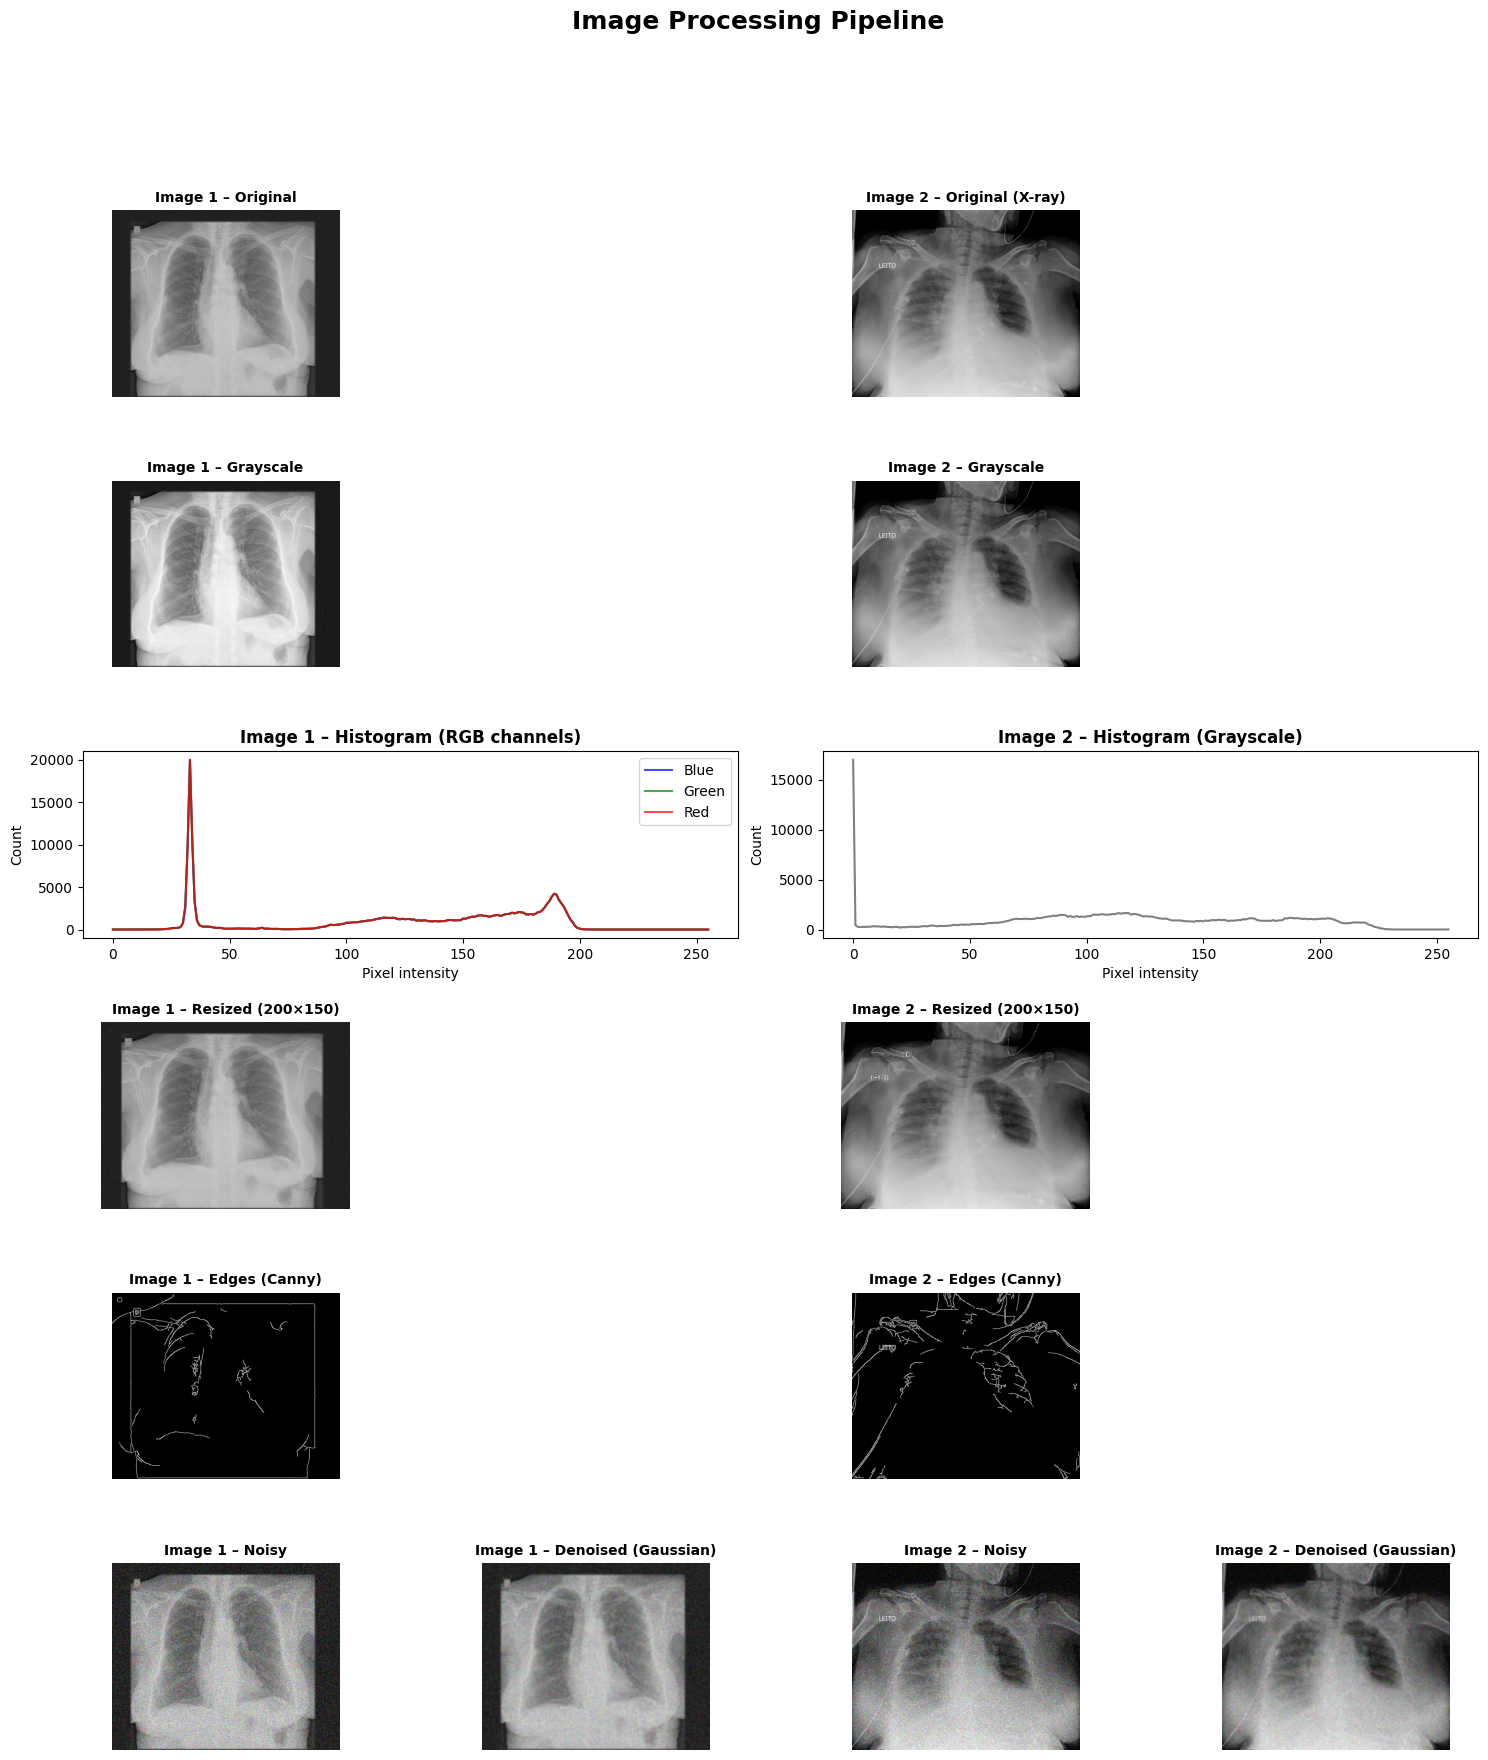

In [36]:
# SAVE OUTPUT

fig.savefig(
    "image_output.png",
    dpi=130,
    bbox_inches="tight"
)

print("Saved → image_output.png")

display(fig)